In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import statsmodels.api as sm
from statsmodels.regression.quantile_regression import QuantReg
from matplotlib.gridspec import GridSpec
from scipy.optimize import curve_fit

from src.config import get_birth_values

import src.config as cfg


    
np.set_printoptions(suppress=True)
pd.options.display.max_columns = None
pd.options.display.max_colwidth = None
pd.options.display.max_rows = None

df = pd.read_csv('data/dataset_mrh_0.9.csv')
df.head()
print(df.shape)


(783, 11)


In [2]:

mod_quarter_const = cfg.mod_quarter_const  # Model 4: y = b*x^(1/4) + c
# Use base config colors explicitly so panel 5 always has Mouse, Mouse_O, Mouse_WO and Rat.
colors_cfg = dict(cfg.colors)

# Fitted parameters for Model 4 (from paper2potencia WLS separate fits)
model4_params = {
    'Rat': {'b': 10.404, 'c': -12.527},
    'Mouse': {'b': 8.715, 'c': -9.547},
}

In [3]:
# Diagnostico rapido: que valores hay en Species
print("Valores unicos en Species:")
print(sorted(df["Species"].dropna().astype(str).str.strip().unique()))
print("\nConteo por Species:")
print(df["Species"].value_counts(dropna=False))

# Separacion directa (keys esperadas: Rat y Mouse)
df_rata = df[df["Species"] == "Rat"].copy()
df_raton = df[df["Species"] == "Mouse"].copy()

print(f"\nFilas Rat: {len(df_rata)}")
print(f"Filas Mouse: {len(df_raton)}")

Valores unicos en Species:
['Human', 'Mouse', 'Rat']

Conteo por Species:
Species
Human    377
Mouse    206
Rat      200
Name: count, dtype: int64

Filas Rat: 200
Filas Mouse: 206


In [4]:
# Diagnostico de columnas para pivot por cluster
print("Columnas:", list(df.columns))
print("\nTipos:")
print(df.dtypes)

cluster_candidates = [c for c in df.columns if c.strip().lower() == "cluster"]
print("\nCluster column:", cluster_candidates[0] if cluster_candidates else "NO ENCONTRADA")

Columnas: ['Species', 'Parameter', 'DAF', 'Reference', 'Obs', 'Quote', 'DOI', 'link', 'Cluster', 'Data_curator', 'GA(H+14)']

Tipos:
Species             str
Parameter           str
DAF             float64
Reference           str
Obs                 str
Quote               str
DOI                 str
link                str
Cluster             str
Data_curator        str
GA(H+14)        float64
dtype: object

Cluster column: Cluster


In [5]:
# Pivot incluyendo Cluster (analisis unificado)
df_pivot_cluster = (
    df.pivot_table(
        index=["Parameter", "Cluster"],
        columns="Species",
        values="DAF",
        aggfunc="mean"
    )
    .reset_index()
)

df_pivot_cluster.columns.name = None

# Comparaciones listas para analisis (sin separar el dataset original)
df_mouse_cluster = df_pivot_cluster[["Parameter", "Cluster", "Human", "Mouse"]].dropna()
df_rat_cluster = df_pivot_cluster[["Parameter", "Cluster", "Human", "Rat"]].dropna()

print("Shape pivot total:", df_pivot_cluster.shape)
print("Shape Human-Mouse:", df_mouse_cluster.shape)
print("Shape Human-Rat:", df_rat_cluster.shape)

print("\nResumen Human-Mouse por cluster:")
print(
    df_mouse_cluster.groupby("Cluster")[["Human", "Mouse"]]
    .median()
    .sort_index()
)

print("\nResumen Human-Rat por cluster:")
print(
    df_rat_cluster.groupby("Cluster")[["Human", "Rat"]]
    .median()
    .sort_index()
)

df_pivot_cluster.head()

Shape pivot total: (375, 5)
Shape Human-Mouse: (194, 4)
Shape Human-Rat: (183, 4)

Resumen Human-Mouse por cluster:
         Human  Mouse
Cluster              
Body      35.0   11.5
Brain     42.0   12.0

Resumen Human-Rat por cluster:
         Human   Rat
Cluster             
Body      51.5  15.0
Brain    105.0  19.0


,Parameter,Cluster,Human,Mouse,Rat
0,1st 7 rills chondrified and in contact with sternum,Body,51.0,14.50,NaN
1,1st and 2nd pharyngeal pouches,Body,23.0,8.33,NaN
2,1st cartilage in otic capsule,Body,48.0,14.50,NaN
3,1st pharyngeal pouch,Body,21.0,8.33,NaN
4,3 bronchial areas in right lung,Body,35.0,11.50,NaN


In [6]:

colors_cfg = cfg.colors

sns.set_theme(style="whitegrid", context="talk")


Panel saved as 'figures/panel5.png'


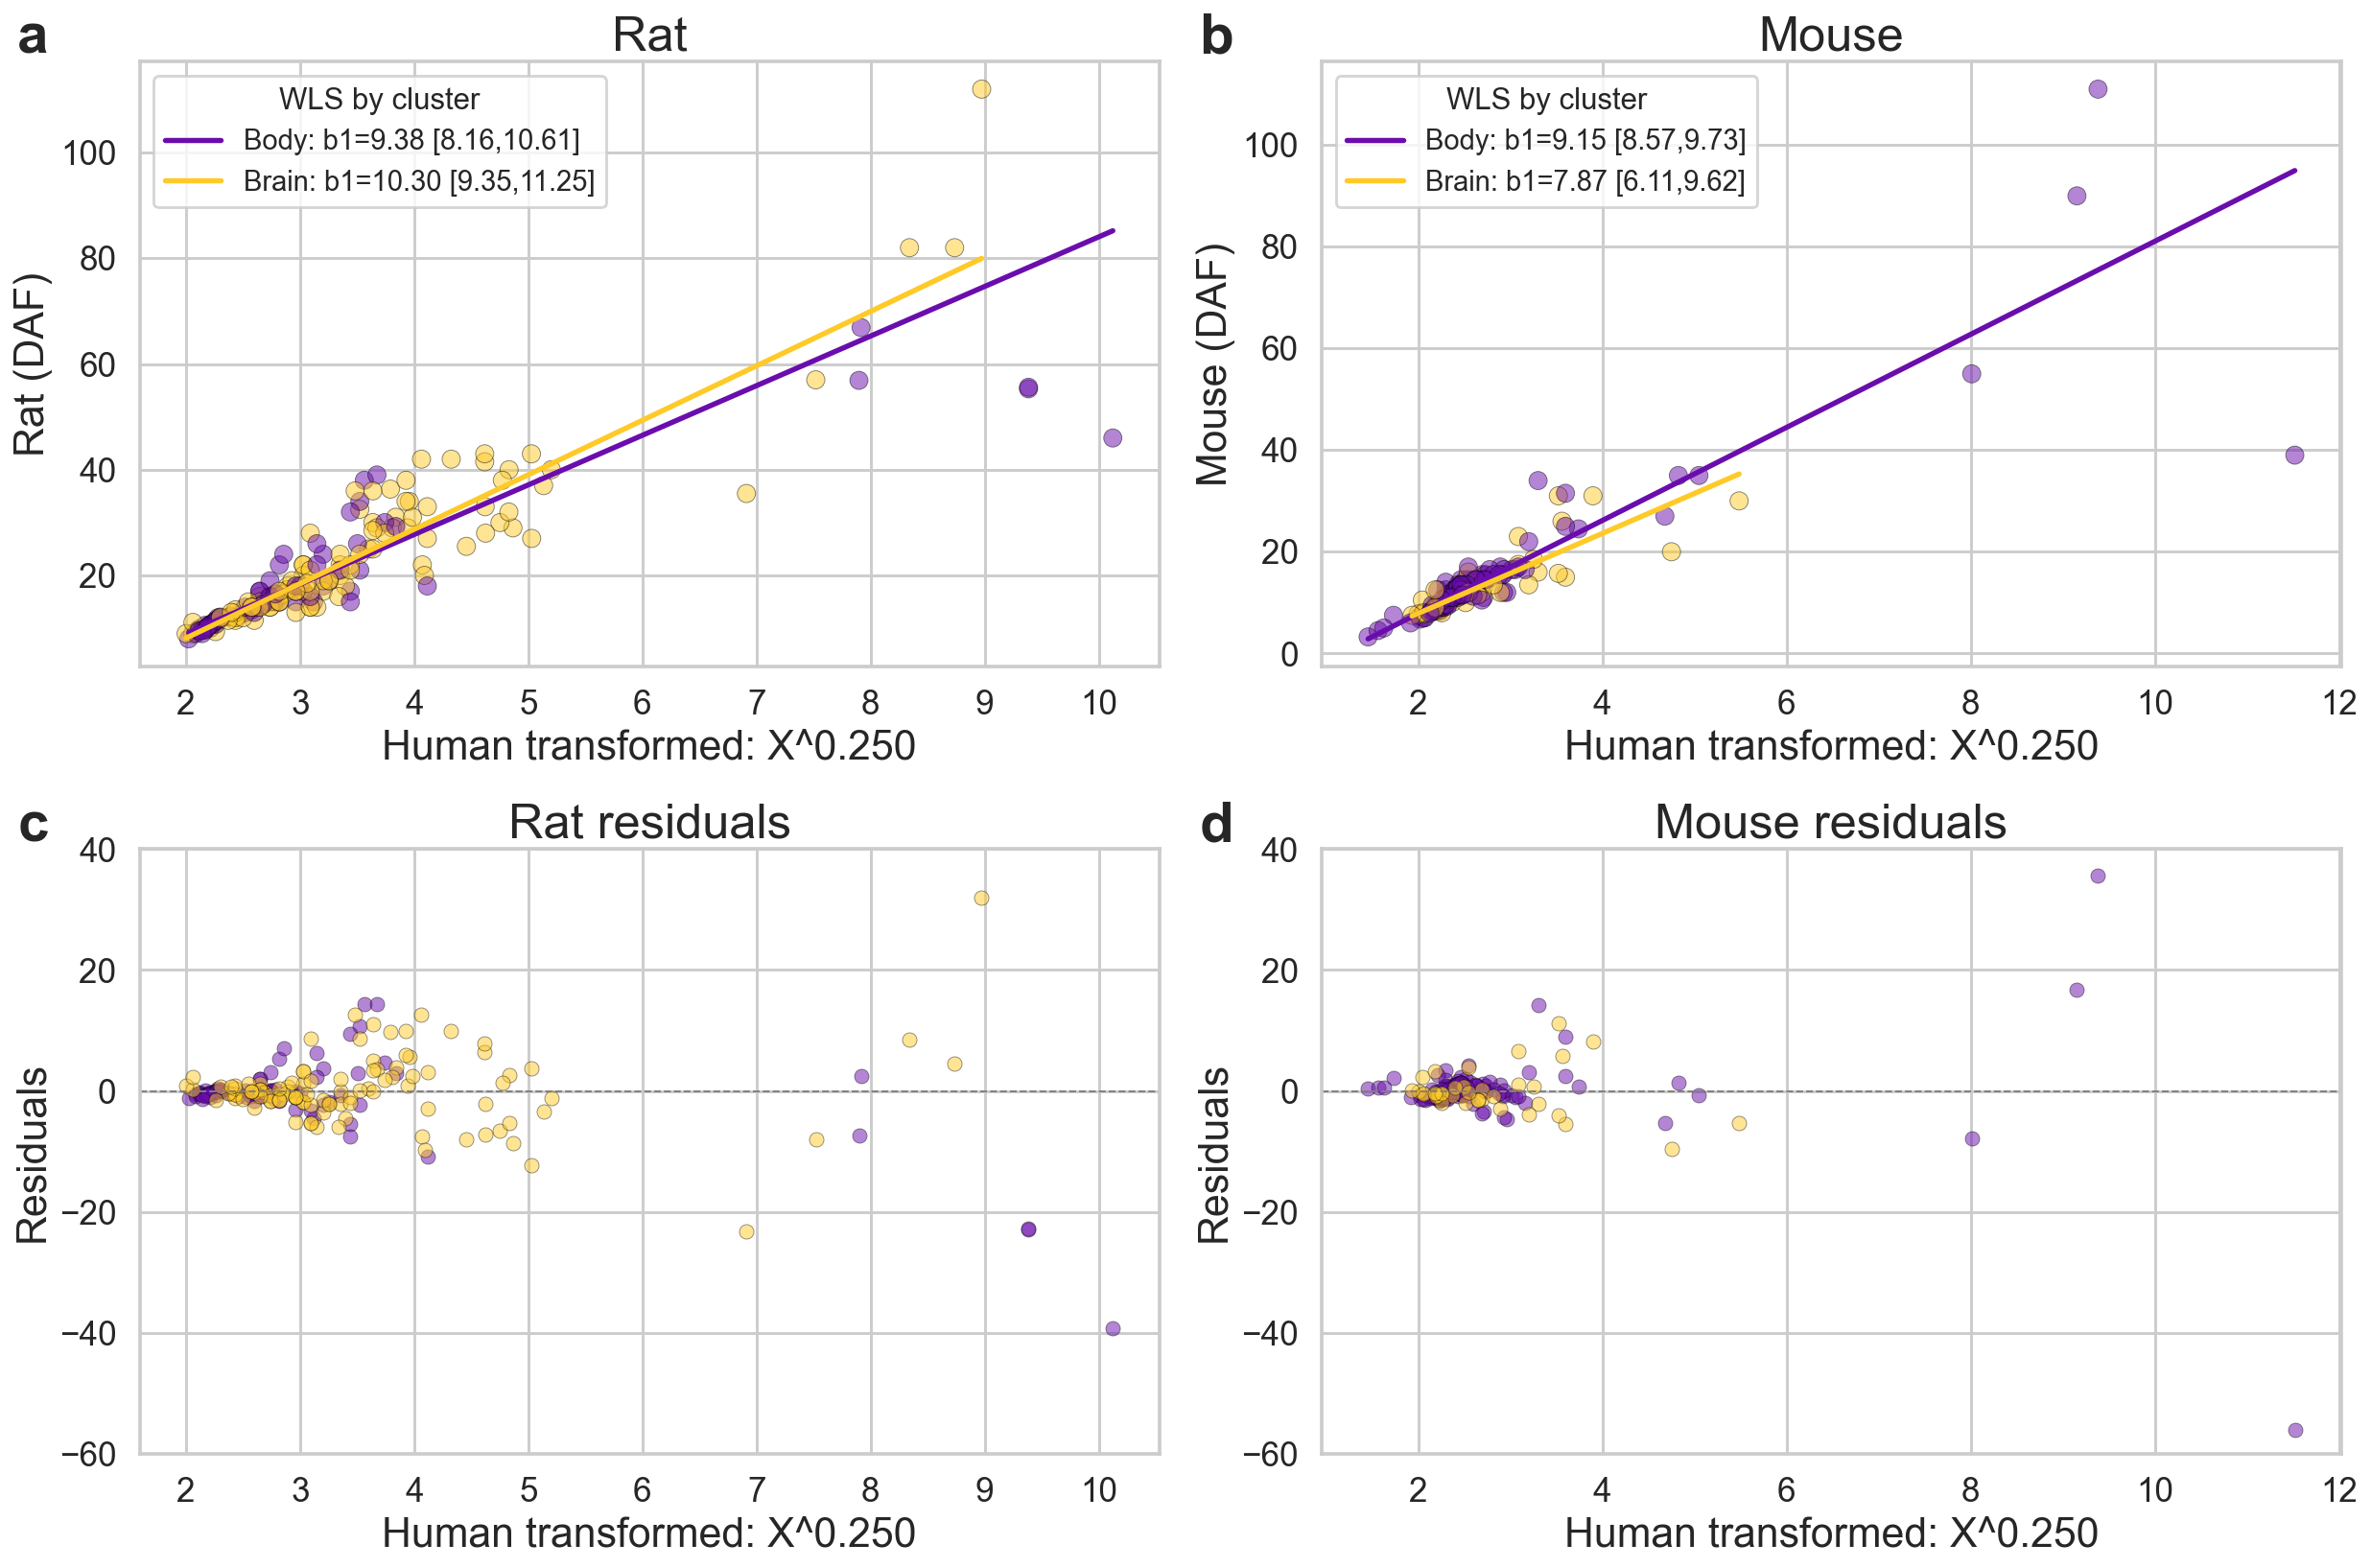

In [7]:
# Panel compacto: linearizacion + WLS por cluster (solo lo necesario para el grafico)


cluster_palette = {
    "Body": colors_cfg["Body"],
    "Brain": colors_cfg["Brain"],
}


def fit_wls_line(x_t, y):
    X = sm.add_constant(x_t)
    ols = sm.OLS(y, X).fit()

    resid2 = np.maximum(ols.resid ** 2, np.finfo(float).eps)
    z = np.log(np.maximum(x_t, np.finfo(float).eps))
    Z = sm.add_constant(z)
    var_model = sm.OLS(np.log(resid2), Z).fit()
    sigma2_hat = np.exp(var_model.predict(Z))
    weights = 1.0 / np.maximum(sigma2_hat, np.finfo(float).eps)

    return sm.WLS(y, X, weights=weights).fit()


def prepare_species_data(df_species, y_col, species_label):
    d = df_species.copy()
    d = d[(d["Human"] > 0) & np.isfinite(d["Human"]) & np.isfinite(d[y_col])]

    
    # Pure transformation (X = x^0.25)
    a = 0.25
    d["Human_t"] = np.power(d["Human"].to_numpy(dtype=float), 0.25)
    return d, a


def draw_panel(ax_fit, ax_res, data, y_col, species_label, a, letter_fit, letter_res):
    sns.scatterplot(
        data=data,
        x="Human_t",
        y=y_col,
        hue="Cluster",
        palette=cluster_palette,
        s=95,
        alpha=0.5,
        edgecolor="black",
        linewidth=0.45,
        legend=False,
        ax=ax_fit,
    )

    for cluster in ["Body", "Brain"]:
        sub = data[data["Cluster"] == cluster]
        if len(sub) < 6:
            continue

        x_t = sub["Human_t"].to_numpy()
        y = sub[y_col].to_numpy()
        wls = fit_wls_line(x_t, y)

        b0, b1 = wls.params
        ci = wls.conf_int(alpha=0.05)
        b1_lo, b1_hi = ci[1]

        x_line = np.linspace(x_t.min(), x_t.max(), 200)
        ax_fit.plot(
            x_line,
            b0 + b1 * x_line,
            color=cluster_palette[cluster],
            linewidth=2.8,
            label=f"{cluster}: b1={b1:.2f} [{b1_lo:.2f},{b1_hi:.2f}]",
        )

        resid = y - wls.predict(sm.add_constant(x_t))
        ax_res.scatter(x_t, resid, color=cluster_palette[cluster], alpha=0.5, s=60, edgecolor="black", linewidth=0.4)

    ax_fit.set_title(f"{species_label}", fontsize=26)
    ax_fit.set_xlabel(f"Human transformed: X^{a:.3f}", fontsize=22)
    ax_fit.set_ylabel(f"{species_label} (DAF)", fontsize=22)
    ax_fit.tick_params(axis="both", labelsize=18)
    ax_fit.legend(loc="upper left", title="WLS by cluster", frameon=True, fontsize=15, title_fontsize=16)

    ax_res.axhline(0, color="grey", linestyle="--", linewidth=1)
    ax_res.set_xlabel(f"Human transformed: X^{a:.3f}", fontsize=22)
    ax_res.set_ylabel("Residuals", fontsize=22)
    ax_res.tick_params(axis="both", labelsize=18)
    ax_res.set_ylim(-60, 40)
    ax_res.set_title(f"{species_label} residuals", fontsize=26)

    # Panel letter identifiers (top-left corner, outside the axes data)
    for ax, letter in [(ax_fit, letter_fit), (ax_res, letter_res)]:
        ax.text(
            -0.12, 1.08, letter,
            transform=ax.transAxes,
            fontsize=30,
            fontweight="bold",
            va="top",
            ha="left",
        )


mouse_data, a_mouse = prepare_species_data(df_mouse_cluster, "Mouse", "Mouse")
rat_data, a_rat = prepare_species_data(df_rat_cluster, "Rat", "Rat")

fig, axes = plt.subplots(2, 2, figsize=(18, 12), dpi=140)
draw_panel(axes[0, 0], axes[1, 0], rat_data, "Rat", "Rat", a_rat, "a", "c")
draw_panel(axes[0, 1], axes[1, 1], mouse_data, "Mouse", "Mouse", a_mouse, "b", "d")
#fig.suptitle("Panel: linearized X + WLS by cluster (with residuals)", fontsize=26)
plt.tight_layout()
# Evita problemas de fuentes en revistas/editoriales
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42



# Guardar en PDF vectorial
plt.savefig(
    'figures/panel5.pdf',
    bbox_inches='tight'
)

# Guardar en TIFF alta resolución
plt.savefig(
    'figures/panel5.tiff',
    dpi=cfg.TIFF_DPI,
    bbox_inches='tight'
)


print("Panel saved as 'figures/panel5.png'")
plt.show()


In [8]:
# Test: is the weighted linear fit (Body vs Brain) significantly different within each species?

def test_cluster_difference(data, y_col, species_label):
    d = data[data["Cluster"].isin(["Body", "Brain"])].copy()
    x = d["Human_t"].to_numpy()
    y = d[y_col].to_numpy()
    D = (d["Cluster"] == "Brain").to_numpy().astype(float)  # 0=Body, 1=Brain

    # Weights from a pooled variance model (log resid^2 ~ log(x))
    resid2 = np.maximum(sm.OLS(y, sm.add_constant(x)).fit().resid ** 2, np.finfo(float).eps)
    Z = sm.add_constant(np.log(np.maximum(x, np.finfo(float).eps)))
    sigma2 = np.maximum(np.exp(sm.OLS(np.log(resid2), Z).fit().predict(Z)), np.finfo(float).eps)
    w = 1.0 / sigma2

    # H0: pooled (same line for both clusters)
    mod_pooled = sm.WLS(y, sm.add_constant(x), weights=w).fit()

    # H1: cluster-specific intercept and slope (dummy + interaction)
    X_full = sm.add_constant(np.column_stack([x, D, x * D]))
    mod_full = sm.WLS(y, X_full, weights=w).fit()

    F_stat, p_global, df_diff = mod_full.compare_f_test(mod_pooled)

    intercept_body, slope_body, delta_intercept, delta_slope = mod_full.params
    p_delta_intercept, p_delta_slope = mod_full.pvalues[2], mod_full.pvalues[3]

    tabla_lineas = pd.DataFrame([
        {"Cluster": "Body", "Intercept": intercept_body, "Slope": slope_body},
        {"Cluster": "Brain", "Intercept": intercept_body + delta_intercept, "Slope": slope_body + delta_slope},
    ])

    tabla_test = pd.DataFrame([
        {"Test": "Joint (intercept + slope) F-test", "Statistic": F_stat, "p_value": p_global},
        {"Test": "Slope difference (Brain - Body)", "Statistic": delta_slope, "p_value": p_delta_slope},
        {"Test": "Intercept difference (Brain - Body)", "Statistic": delta_intercept, "p_value": p_delta_intercept},
    ])

    print(f"=== {species_label} | Body vs Brain (weighted linear fit) ===")
    print(f"Joint F-test: F={F_stat:.4f}, p={p_global:.6g}")
    print("Interpretation (alpha=0.05):", "SIGNIFICANTLY DIFFERENT lines" if p_global < 0.05 else "NOT significantly different")
    display(tabla_lineas.round(6))
    display(tabla_test.round(6))
    print()

    return tabla_lineas, tabla_test


_ = test_cluster_difference(mouse_data, "Mouse", "Mouse")
_ = test_cluster_difference(rat_data, "Rat", "Rat")

=== Mouse | Body vs Brain (weighted linear fit) ===
Joint F-test: F=1.9518, p=0.144851
Interpretation (alpha=0.05): NOT significantly different


,Cluster,Intercept,Slope
0,Body,-10.110461,8.995443
1,Brain,-7.879912,7.871313


,Test,Statistic,p_value
0,Joint (intercept + slope) F-test,1.951829,0.144851
1,Slope difference (Brain - Body),-1.124130,0.132867
2,Intercept difference (Brain - Body),2.230549,0.196510



=== Rat | Body vs Brain (weighted linear fit) ===
Joint F-test: F=0.4789, p=0.620273
Interpretation (alpha=0.05): NOT significantly different


,Cluster,Intercept,Slope
0,Body,-12.731211,10.549909
1,Brain,-13.030330,10.509227


,Test,Statistic,p_value
0,Joint (intercept + slope) F-test,0.478872,0.620273
1,Slope difference (Brain - Body),-0.040682,0.959227
2,Intercept difference (Brain - Body),-0.299118,0.885960


In [9]:
# Joint model: Rat vs Mouse combined, with dummy D (1=Rat, 0=Mouse)

def test_species_difference(mouse_df, rat_df):
    x_m = mouse_df["Human_t"].to_numpy()
    y_m = mouse_df["Mouse"].to_numpy()
    x_r = rat_df["Human_t"].to_numpy()
    y_r = rat_df["Rat"].to_numpy()

    x = np.concatenate([x_m, x_r])
    y = np.concatenate([y_m, y_r])
    D = np.concatenate([np.zeros_like(x_m), np.ones_like(x_r)])  # 0=Mouse, 1=Rat

    # Weights from a pooled variance model (log resid^2 ~ log(x))
    resid2 = np.maximum(sm.OLS(y, sm.add_constant(x)).fit().resid ** 2, np.finfo(float).eps)
    Z = sm.add_constant(np.log(np.maximum(x, np.finfo(float).eps)))
    sigma2 = np.maximum(np.exp(sm.OLS(np.log(resid2), Z).fit().predict(Z)), np.finfo(float).eps)
    w = 1.0 / sigma2

    # H0: pooled (same line for both species)
    mod_pooled = sm.WLS(y, sm.add_constant(x), weights=w).fit()

    # H1: species-specific intercept and slope (dummy + interaction)
    X_full = sm.add_constant(np.column_stack([x, D, x * D]))
    mod_full = sm.WLS(y, X_full, weights=w).fit()

    F_stat, p_global, df_diff = mod_full.compare_f_test(mod_pooled)

    intercept_mouse, slope_mouse, delta_intercept, delta_slope = mod_full.params
    p_delta_intercept, p_delta_slope = mod_full.pvalues[2], mod_full.pvalues[3]

    tabla_lineas = pd.DataFrame([
        {"Species": "Mouse", "Intercept": intercept_mouse, "Slope": slope_mouse},
        {"Species": "Rat", "Intercept": intercept_mouse + delta_intercept, "Slope": slope_mouse + delta_slope},
    ])

    tabla_test = pd.DataFrame([
        {"Test": "Joint (intercept + slope) F-test", "Statistic": F_stat, "p_value": p_global},
        {"Test": "Slope difference (Rat - Mouse)", "Statistic": delta_slope, "p_value": p_delta_slope},
        {"Test": "Intercept difference (Rat - Mouse)", "Statistic": delta_intercept, "p_value": p_delta_intercept},
    ])

    print("=== Rat vs Mouse | joint weighted linear model (D=1 Rat, D=0 Mouse) ===")
    print(f"Joint F-test: F={F_stat:.4f}, p={p_global:.6g}")
    print("Interpretation (alpha=0.05):", "SIGNIFICANTLY DIFFERENT lines" if p_global < 0.05 else "NOT significantly different")
    display(tabla_lineas.round(6))
    display(tabla_test.round(6))

    return tabla_lineas, tabla_test


_ = test_species_difference(mouse_data, rat_data)

=== Rat vs Mouse | joint weighted linear model (D=1 Rat, D=0 Mouse) ===
Joint F-test: F=19.8036, p=6.70009e-09
Interpretation (alpha=0.05): SIGNIFICANTLY DIFFERENT lines


,Species,Intercept,Slope
0,Mouse,-9.790120,8.825049
1,Rat,-12.613931,10.434510


,Test,Statistic,p_value
0,Joint (intercept + slope) F-test,19.803607,0.000000
1,Slope difference (Rat - Mouse),1.609461,0.000369
2,Intercept difference (Rat - Mouse),-2.823811,0.009940


In [10]:
# Cluster effect (Brain vs Body) within the joint Rat+Mouse model, controlling for species

def test_cluster_effect_joint(mouse_df, rat_df):
    x_m = mouse_df["Human_t"].to_numpy()
    y_m = mouse_df["Mouse"].to_numpy()
    c_m = (mouse_df["Cluster"] == "Brain").to_numpy().astype(float)

    x_r = rat_df["Human_t"].to_numpy()
    y_r = rat_df["Rat"].to_numpy()
    c_r = (rat_df["Cluster"] == "Brain").to_numpy().astype(float)

    x = np.concatenate([x_m, x_r])
    y = np.concatenate([y_m, y_r])
    Ds = np.concatenate([np.zeros_like(x_m), np.ones_like(x_r)])  # species dummy: 0=Mouse, 1=Rat
    Dc = np.concatenate([c_m, c_r])  # cluster dummy: 1=Brain, 0=Body

    # Weights from a pooled variance model (log resid^2 ~ log(x))
    resid2 = np.maximum(sm.OLS(y, sm.add_constant(x)).fit().resid ** 2, np.finfo(float).eps)
    Z = sm.add_constant(np.log(np.maximum(x, np.finfo(float).eps)))
    sigma2 = np.maximum(np.exp(sm.OLS(np.log(resid2), Z).fit().predict(Z)), np.finfo(float).eps)
    w = 1.0 / sigma2

    # H0: species-only model (no cluster effect)
    mod_species = sm.WLS(y, sm.add_constant(np.column_stack([x, Ds, x * Ds])), weights=w).fit()

    # H1: species + cluster (dummy + interaction), controlling for species
    X_full = sm.add_constant(np.column_stack([x, Ds, x * Ds, Dc, x * Dc]))
    mod_full = sm.WLS(y, X_full, weights=w).fit()

    F_stat, p_global, df_diff = mod_full.compare_f_test(mod_species)

    delta_intercept_cluster, delta_slope_cluster = mod_full.params[4], mod_full.params[5]
    p_delta_intercept_cluster, p_delta_slope_cluster = mod_full.pvalues[4], mod_full.pvalues[5]

    tabla_test = pd.DataFrame([
        {"Test": "Joint Cluster effect (intercept + slope) F-test", "Statistic": F_stat, "p_value": p_global},
        {"Test": "Slope difference (Brain - Body)", "Statistic": delta_slope_cluster, "p_value": p_delta_slope_cluster},
        {"Test": "Intercept difference (Brain - Body)", "Statistic": delta_intercept_cluster, "p_value": p_delta_intercept_cluster},
    ])

    print("=== Brain vs Body | effect within the joint Rat+Mouse model (controlling for species) ===")
    print(f"Joint F-test: F={F_stat:.4f}, p={p_global:.6g}")
    print("Interpretation (alpha=0.05):", "SIGNIFICANTLY DIFFERENT lines" if p_global < 0.05 else "NOT significantly different")
    display(tabla_test.round(6))

    return tabla_test


_ = test_cluster_effect_joint(mouse_data, rat_data)

=== Brain vs Body | effect within the joint Rat+Mouse model (controlling for species) ===
Joint F-test: F=2.4979, p=0.0836393
Interpretation (alpha=0.05): NOT significantly different


,Test,Statistic,p_value
0,Joint Cluster effect (intercept + slope) F-test,2.497910,0.083639
1,Slope difference (Brain - Body),-0.769041,0.138172
2,Intercept difference (Brain - Body),1.470409,0.241687
